# Compare 0407 notebook input vs production video process

Subject: `aaisyah_nursalsabiil_ni_patriarti_after`

Clip: `q1`

Goal: compare the reference notebook input (`npy_path`) against the production raw-video path used by `src/api/video_process.py`, using the direct ROI spotter contract.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

from src.apex.modules import ApexPhaseSpotterROI

ANNOTATION_PATH = Path("/home/inadio/datasets/anxiety_raw/annotations-v10-clips.csv")
SUBJECT_ID = "aaisyah_nursalsabiil_ni_patriarti_after"
CLIP = "q1"

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 160)
print("Annotation path:", ANNOTATION_PATH)
print("Subject:", SUBJECT_ID, "| clip:", CLIP)

Annotation path: /home/inadio/datasets/anxiety_raw/annotations-v10-clips.csv
Subject: aaisyah_nursalsabiil_ni_patriarti_after | clip: q1


In [2]:
df = pd.read_csv(ANNOTATION_PATH)
if "npy_path" not in df.columns and "cache_path" in df.columns:
    df["npy_path"] = df["cache_path"]
if "is_valid" in df.columns:
    df = df[df["is_valid"]].copy()

row = df[(df["subject_id"] == SUBJECT_ID) & (df["clip"] == CLIP)].iloc[0]
display(row[["subject_id", "clip", "label", "stage", "video_path", "npy_path"]].to_frame().T)

video_path = Path(row["video_path"])
reference_path = Path(row["npy_path"])
print("video exists:", video_path.exists())
print("reference npz exists:", reference_path.exists())

def load_reference_flow(npz_path: Path) -> np.ndarray:
    data = np.load(npz_path, allow_pickle=False)
    if isinstance(data, np.lib.npyio.NpzFile):
        with data as npz:
            if "flow" in npz:
                return npz["flow"].astype(np.float32)
            if "dx" in npz and "dy" in npz:
                dx = npz["dx"].astype(np.float32)
                dy = npz["dy"].astype(np.float32)
                return np.stack([dx, dy], axis=-1).astype(np.float32)
    raise KeyError(f"Unsupported flow archive: {npz_path}")

reference_flow = load_reference_flow(reference_path)
print("reference_flow shape:", reference_flow.shape)

,subject_id,clip,label,stage,video_path,npy_path
0,aaisyah_nursalsabiil_ni_patriarti_after,q1,anxiety_tinggi,after,/home/inadio/datasets/anxiety_raw/after/anxiety/aaisyah_nursalsabiil_ni_patriarti_1765170495474/q1/Aaisyah Nursalsabiil Ni Patriarti_1_15d591ce-051a-47f2-ac38-367c1e6189c7_main.webm,/home/inadio/datasets/anxiety_raw/.cache_npy_v10/after/anxiety/aaisyah_nursalsabiil_ni_patriarti_1765170495474/q1/Aaisyah Nursalsabiil Ni Patriarti_1_15d591ce-051a-47f2-ac38-367c1e6189c7_main.npz


video exists: True
reference npz exists: True
reference_flow shape: (480, 5, 2, 64, 64)


In [3]:
reference_spotter = ApexPhaseSpotterROI()
reference_windows, reference_meta = reference_spotter.detect_windows(
    reference_flow,
    phase_mode="onset_to_apex",
)

reference_smoothed = np.asarray(reference_meta.get("smoothed_signal", []), dtype=np.float32)
reference_summary = pd.DataFrame(
    [
        {
            "source": "0407 notebook reference",
            "signal_length": int(reference_meta.get("signal_length", len(reference_smoothed))),
            "valid": bool(reference_meta.get("valid", False)),
            "reason": reference_meta.get("reason"),
            "num_peaks": reference_meta.get("num_peaks"),
            "num_windows": reference_meta.get("num_windows"),
            "confidence": reference_meta.get("confidence"),
            "apex_indices": [apex for _, apex, _ in reference_windows],
        }
    ]
)
display(reference_summary)
print("reference windows:", reference_windows)


W0000 00:00:1780579256.119471 2945703 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780579256.125919 2945705 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780579256.140422 2945705 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


,source,signal_length,valid,reason,num_peaks,num_windows,confidence,apex_indices
0,0407 notebook reference,480,True,ok,4,4,1.735576,"[86, 314, 357, 460]"


reference windows: [(68, 86, 87), (294, 314, 315), (337, 357, 358), (443, 460, 461)]


In [4]:
production_spotter = ApexPhaseSpotterROI()
production_apex_indices, production_phases = production_spotter.process(str(video_path))
production_raw_magnitudes = np.asarray(production_spotter.magnitudes, dtype=np.float32)
production_windows, production_meta = production_spotter.detect_windows_from_signal(
    production_raw_magnitudes,
    phase_mode="onset_to_apex",
)

production_smoothed = np.asarray(production_meta.get("smoothed_signal", []), dtype=np.float32)
production_summary = pd.DataFrame(
    [
        {
            "source": "production video_process path (ApexPhaseSpotterROI)",
            "signal_length": int(production_meta.get("signal_length", len(production_raw_magnitudes))),
            "valid": bool(production_meta.get("valid", False)),
            "reason": production_meta.get("reason"),
            "num_peaks": production_meta.get("num_peaks"),
            "num_windows": production_meta.get("num_windows"),
            "confidence": production_meta.get("confidence"),
            "apex_indices": production_apex_indices,
        }
    ]
)
display(production_summary)
print("production phases:", production_phases)
print("production windows:", production_windows)


W0000 00:00:1780579256.177195 2945725 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1780579256.183529 2945729 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780579256.192923 2945729 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


,source,signal_length,valid,reason,num_peaks,num_windows,confidence,apex_indices
0,production video_process path (ApexPhaseSpotterROI),480,True,ok,4,4,1.695914,"[85, 310, 358, 460]"


production phases: {85: {'start': 73, 'end': 85}, 310: {'start': 298, 'end': 310}, 358: {'start': 344, 'end': 358}, 460: {'start': 445, 'end': 460}}
production windows: [(68, 85, 86), (293, 310, 311), (339, 358, 359), (440, 460, 461)]


,source,signal_shape,signal_length,num_windows,apex_indices
0,reference npz,"(480, 5, 2, 64, 64)",480,4,"[86, 314, 357, 460]"
1,production video,"(480,)",480,4,"[85, 310, 358, 460]"


Delta summary:
- reference valid: True
- production valid: True
- same apex count: True
- same signal length: True


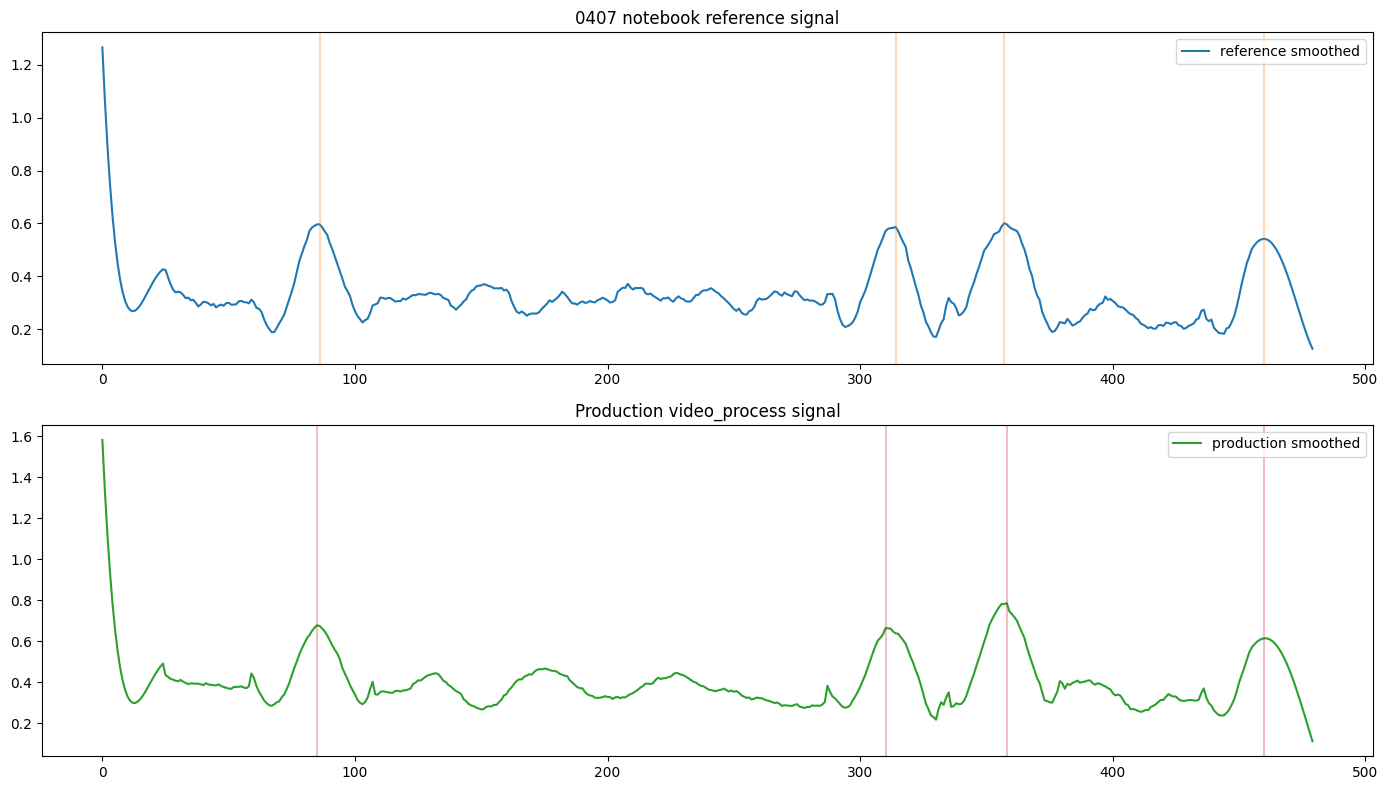

In [5]:
compare_rows = [
    {
        "source": "reference npz",
        "signal_shape": tuple(reference_flow.shape),
        "signal_length": int(reference_summary.iloc[0]["signal_length"]),
        "num_windows": int(reference_summary.iloc[0]["num_windows"] or 0),
        "apex_indices": reference_summary.iloc[0]["apex_indices"],
    },
    {
        "source": "production video",
        "signal_shape": tuple(production_raw_magnitudes.shape),
        "signal_length": int(production_summary.iloc[0]["signal_length"]),
        "num_windows": int(production_summary.iloc[0]["num_windows"] or 0),
        "apex_indices": production_summary.iloc[0]["apex_indices"],
    },
]
compare_df = pd.DataFrame(compare_rows)
display(compare_df)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
if reference_smoothed.size:
    axes[0].plot(reference_smoothed, label="reference smoothed", color="tab:blue")
    for _, apex, _ in reference_windows:
        axes[0].axvline(apex, color="tab:orange", alpha=0.3)
    axes[0].set_title("0407 notebook reference signal")
    axes[0].legend(loc="upper right")
if production_smoothed.size:
    axes[1].plot(production_smoothed, label="production smoothed", color="tab:green")
    for apex in production_apex_indices:
        axes[1].axvline(apex, color="tab:red", alpha=0.3)
    axes[1].set_title("Production video_process signal")
    axes[1].legend(loc="upper right")
plt.tight_layout()

print("Delta summary:")
print("- reference valid:", bool(reference_meta.get("valid", False)))
print("- production valid:", bool(production_meta.get("valid", False)))
print("- same apex count:", len(reference_windows) == len(production_apex_indices))
print("- same signal length:", int(reference_summary.iloc[0]["signal_length"]) == int(production_summary.iloc[0]["signal_length"]))
